# Analise sequencial de similatidade entre cortes centrais

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [2]:
def parse_log(log_data):
    records = []
    current_record = {}

    for line in log_data.strip().split('\n'):
        line = line.strip()
        if line.startswith('ID da Imagem:'):
            current_record['ID da Imagem'] = line.split(': ')[1]
        elif line.startswith('Quantidade de cortes B avaliados:'):
            current_record['Cortes Avaliados'] = int(line.split(': ')[1])
        elif line.startswith('Tempo de Leitura Total (A+B):'):
            current_record['Tempo Leitura Total (s)'] = float(line.split(': ')[1].replace(' s', ''))
        elif line.startswith('Tempo Medio Calculo SSIM (por slice):'):
            current_record['Tempo Medio SSIM (s)'] = float(line.split(': ')[1].replace(' s', ''))
        elif line.startswith('Tempo de Busca (SSIM loop):'):
            current_record['Tempo Busca (s)'] = float(line.split(': ')[1].replace(' s', ''))
        elif line.startswith('Tempo Total do Processo:'):
            current_record['Tempo Total (s)'] = float(line.split(': ')[1].replace(' s', ''))
        elif line.startswith('Melhor Slice (Z):'):
            current_record['Melhor Slice'] = int(line.split(': ')[1])
        elif line.startswith('SSIM Maximo Encontrado:'):
            current_record['SSIM Maximo'] = float(line.split(': ')[1])
            records.append(current_record)
            current_record = {}
    return pd.DataFrame(records)

In [3]:
file_path = "data/log.txt"
if os.path.exists(file_path):
    with open(file_path, 'r') as f:
        log_content = f.read()
    data_records = parse_log(log_content)
    df = pd.DataFrame(data_records)
else:
    print(f"Arquivo {file_path} não encontrado.")

In [4]:
df.head()

,ID da Imagem,Cortes Avaliados,Tempo Leitura Total (s),Tempo Medio SSIM (s),Tempo Busca (s),Tempo Total (s),Melhor Slice,SSIM Maximo
0,TRV1P1,64,0.941949,0.025015,1.64520,2.58881,1,0.787530
1,TRV1P2,56,0.743664,0.025129,1.44664,2.19187,10,0.787048
2,TRV1P3,56,0.868253,0.024378,1.40051,2.27028,1,0.738336
3,TRV1P4,64,1.006330,0.024366,1.60302,2.61108,33,0.789451
4,TRV1P5,48,1.147660,0.026596,1.31149,2.46042,1,0.798552


In [5]:
media_leitura = df['Tempo Leitura Total (s)'].mean()
media_calculo_ssim = df['Tempo Medio SSIM (s)'].mean()
media_tempo_busca = df['Tempo Busca (s)'].mean()
media_tempo_total = df['Tempo Total (s)'].mean()

print("========== INSIGHTS GERAIS ==========")
print(f"Média de Tempo de Leitura: {media_leitura:.4f} s")
print(f"Média de Cálculo SSIM (por slice): {media_calculo_ssim:.4f} s")
print(f"Média do Tempo de Busca (loop geral): {media_tempo_busca:.4f} s")
print(f"Média do Tempo Total de Processo: {media_tempo_total:.4f} s")
print("=====================================")

========== INSIGHTS GERAIS ==========
Média de Tempo de Leitura: 1.5333 s
Média de Cálculo SSIM (por slice): 0.0288 s
Média do Tempo de Busca (loop geral): 1.4156 s
Média do Tempo Total de Processo: 2.9505 s


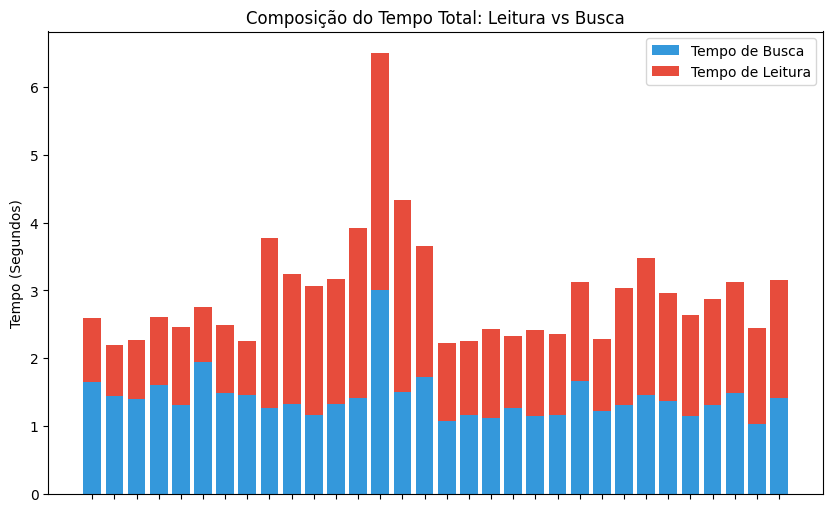

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(df['ID da Imagem'], df['Tempo Busca (s)'], label='Tempo de Busca', color='#3498db')
ax.bar(df['ID da Imagem'], df['Tempo Leitura Total (s)'], bottom=df['Tempo Busca (s)'], label='Tempo de Leitura', color='#e74c3c')

ax.set_ylabel('Tempo (Segundos)')
ax.set_title('Composição do Tempo Total: Leitura vs Busca')
ax.tick_params(axis='x', labelbottom=False)
ax.legend()
plt.show()

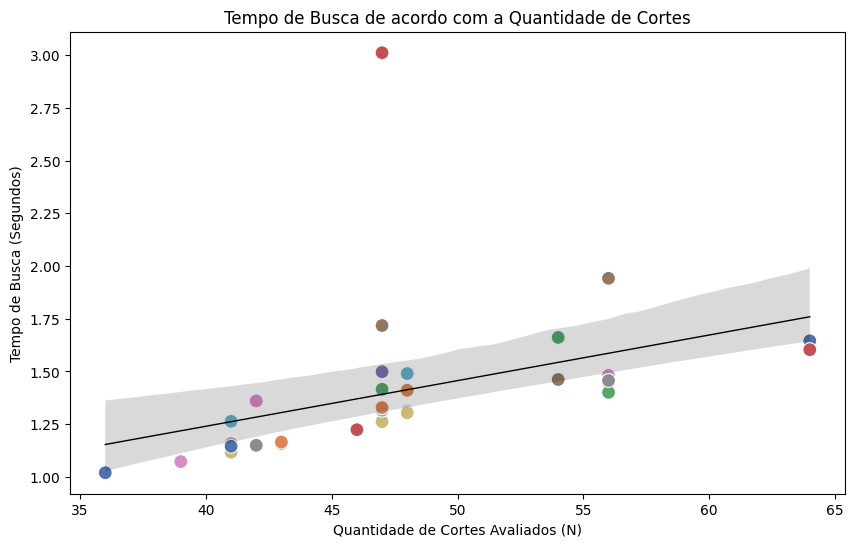

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='Cortes Avaliados', 
    y='Tempo Busca (s)', 
    hue='ID da Imagem', 
    s=100, # tamanho das bolinhas
    palette='deep',
    legend=False
)

sns.regplot(
    data=df,
    x='Cortes Avaliados',
    y='Tempo Busca (s)',
    scatter=False,
    color='black',
    line_kws={'linewidth': 1}
)

plt.title('Tempo de Busca de acordo com a Quantidade de Cortes')
plt.ylabel('Tempo de Busca (Segundos)')
plt.xlabel('Quantidade de Cortes Avaliados (N)')
plt.show()

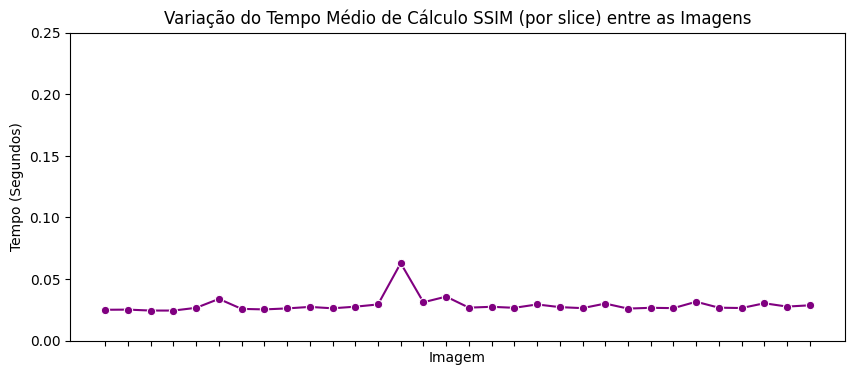

In [8]:
plt.figure(figsize=(10, 4))
sns.lineplot(
    data=df, 
    x='ID da Imagem', 
    y='Tempo Medio SSIM (s)', 
    marker='o',
    color='purple',
    legend=False
)
plt.title('Variação do Tempo Médio de Cálculo SSIM (por slice) entre as Imagens')
plt.tick_params(axis='x', labelbottom=False)
plt.ylabel('Tempo (Segundos)')
plt.xlabel('Imagem')
plt.ylim(0, 0.25)
plt.show()